In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import sys
import os
from pathlib import Path

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
sys.path.append('../')

In [4]:
from src.data_loader import load_bitcoin_data, check_missing_values

In [5]:
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)
os.makedirs("../results/plots", exist_ok=True)

In [6]:
btc_data=load_bitcoin_data(start_date="2015-01-01", end_date="2025-05-01")
print(f"\nData shape: {btc_data.shape}")
print(f"Data range: {btc_data.index[0]} to {btc_data.index[-1]}")

[*********************100%***********************]  1 of 1 completed

Downloaded 3773 rows
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

Data shape: (3773, 5)
Data range: 2015-01-01 00:00:00 to 2025-04-30 00:00:00


In [7]:
btc_data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


In [8]:
btc_data.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-04-26,94646.929688,95251.359375,93927.250000,94714.648438,17612825123
2025-04-27,93754.843750,95301.203125,93665.398438,94660.906250,18090367764
2025-04-28,94978.750000,95598.492188,92860.804688,93755.304688,32363449569
2025-04-29,94284.789062,95485.414062,93796.632812,94981.859375,25806129921
2025-04-30,94207.312500,95249.320312,92979.640625,94286.468750,28344679831


In [9]:
btc_data.dtypes

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [10]:
has_no_missing=check_missing_values(btc_data)
if has_no_missing:
    print("Data quality ok")
else:
    btc_data=btc_data.ffill()

No missing values
Data quality ok


### Basic Statistics

In [11]:
print(btc_data[['Close']].describe())
print(f"\nClose price range: ${btc_data['Close'].min():.2f} - ${btc_data['Close'].max():.2f}")
print(f"Average daily return: {btc_data['Close'].pct_change().mean()*100:.4f}%")

Price          Close
count    3773.000000
mean    22418.074351
std     25227.642181
min       178.102997
25%      2875.340088
50%     10181.641602
75%     36702.597656
max    106146.265625

Close price range: $178.10 - $106146.27
Average daily return: 0.2167%


In [12]:
btc_data.to_csv("../data/raw/bitcoin.csv")

## EDA

### Price history

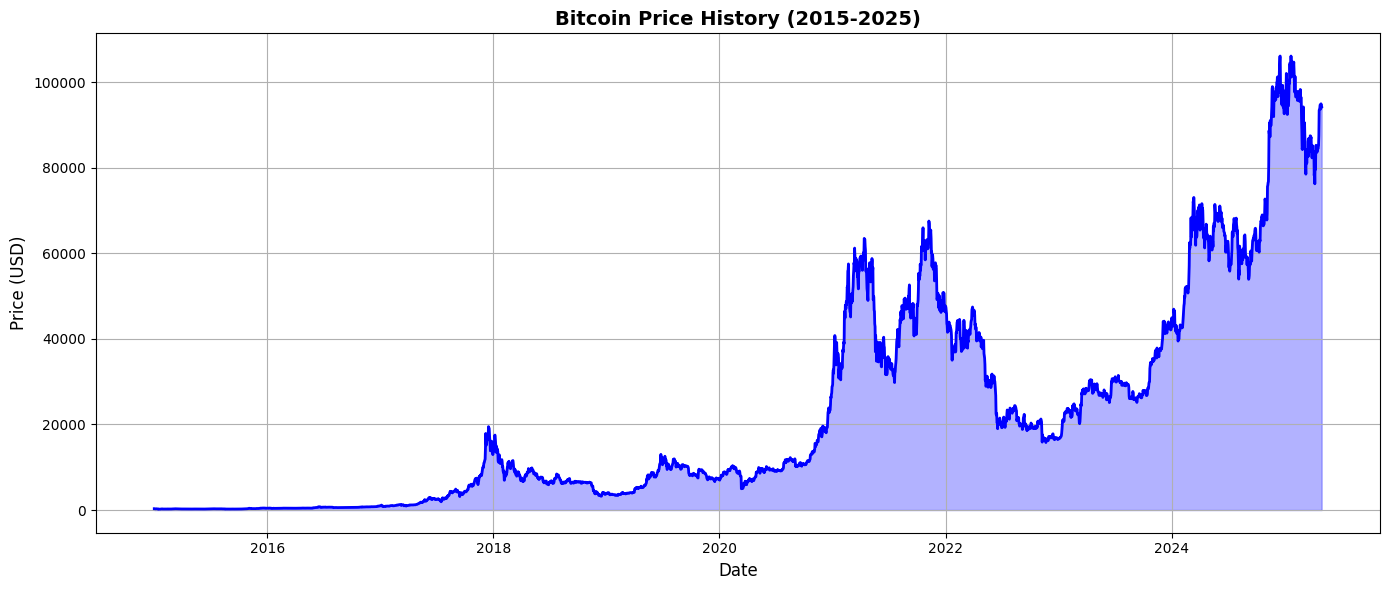

In [13]:
fig,ax=plt.subplots(figsize=(14,6))

ax.plot(btc_data.index,btc_data['Close'],linewidth=2,color='blue')
ax.fill_between(btc_data.index,btc_data['Close'],alpha=0.3,color='blue')

ax.set_xlabel('Date',fontsize=12)
ax.set_ylabel('Price (USD)',fontsize=12)
ax.set_title('Bitcoin Price History (2015-2025)', fontsize=14, fontweight='bold')

ax.grid()
plt.tight_layout()
plt.savefig("../results/plots/01_price_history.png", dpi=150)
plt.show()

### Close price distribution

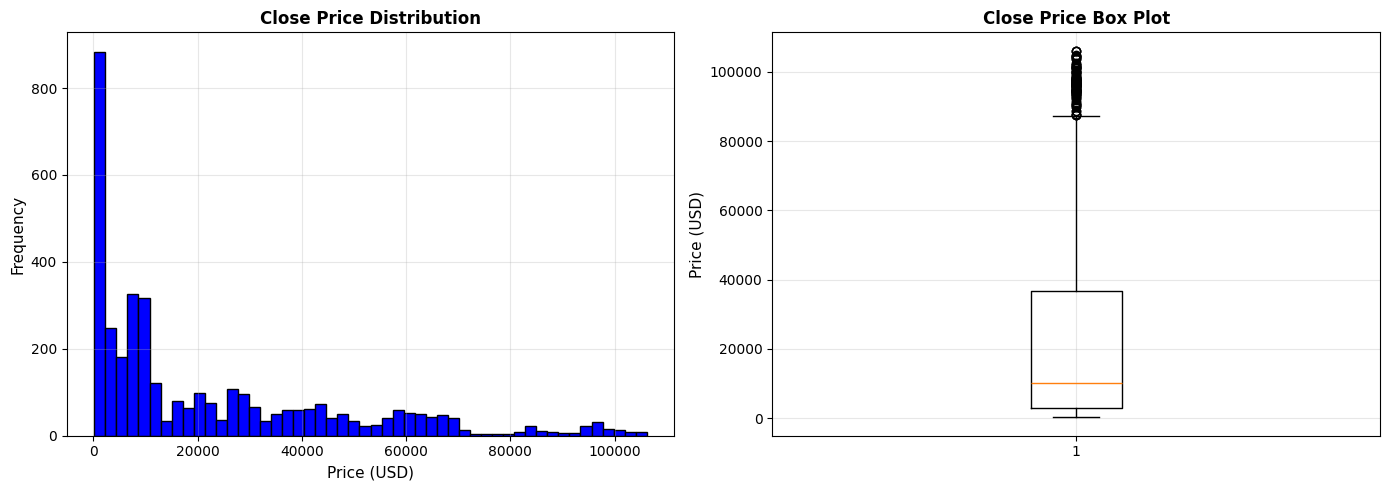

In [14]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,5))

ax1.hist(btc_data['Close'],bins=50,edgecolor='black',color='blue')
ax1.set_xlabel('Price (USD)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Close Price Distribution', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.boxplot(btc_data['Close'],vert=True)
ax2.set_ylabel('Price (USD)', fontsize=11)
ax2.set_title('Close Price Box Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/plots/02_price_distribution.png", dpi=150)
plt.show()

### Plot daily returns

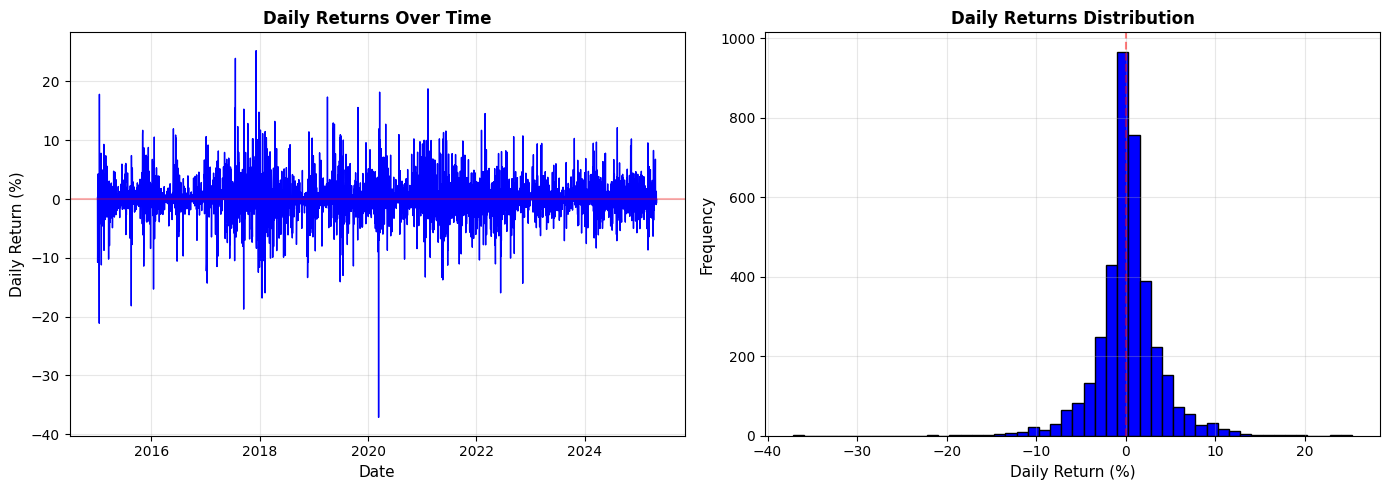

In [15]:
daily_returns=btc_data['Close'].pct_change()*100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(btc_data.index[1:], daily_returns[1:],linewidth=1,color='blue')
ax1.axhline(y=0,color='red',linestyle='-',alpha=0.3)
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Daily Return (%)', fontsize=11)
ax1.set_title('Daily Returns Over Time', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.hist(daily_returns[1:],bins=50,edgecolor='black',color='blue')
ax2.set_xlabel('Daily Return (%)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Daily Returns Distribution', fontsize=12, fontweight='bold')
ax2.axvline(x=0,color='red',linestyle='--',alpha=0.5)
ax2.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig("../results/plots/03_daily_returns.png", dpi=150)
plt.show()

In [16]:
print(f"Daily Returns Stats:")
print(f"  Mean: {daily_returns.mean():.4f}%")
print(f"  Std:  {daily_returns.std():.4f}%")
print(f"  Min:  {daily_returns.min():.4f}%")
print(f"  Max:  {daily_returns.max():.4f}%")

Daily Returns Stats:
  Mean: 0.2167%
  Std:  3.6030%
  Min:  -37.1695%
  Max:  25.2472%


### Plot volume trend

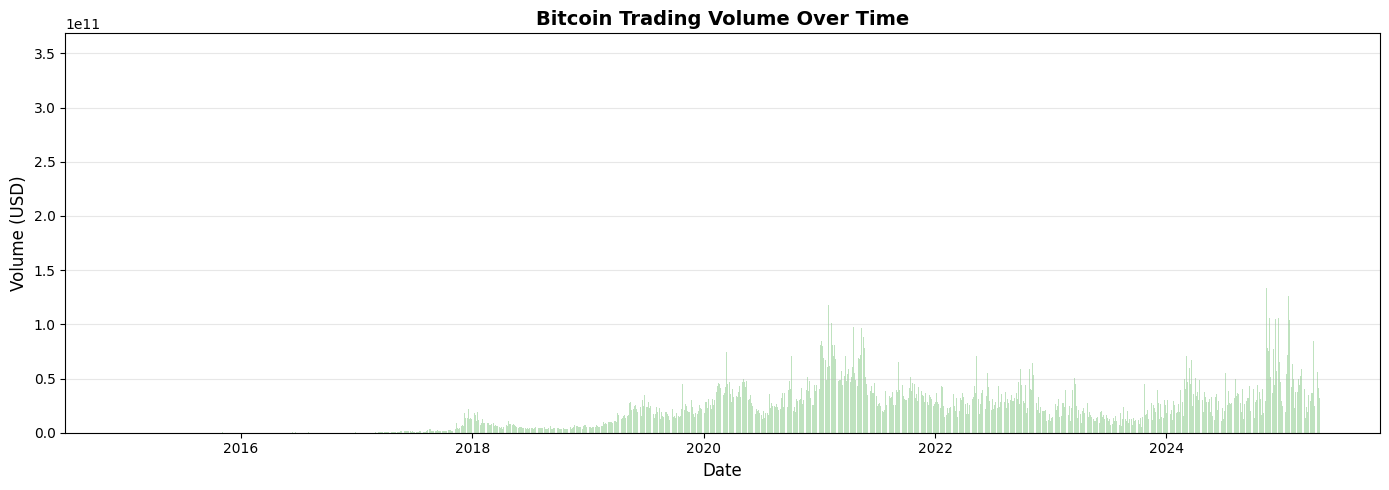

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(btc_data.index,btc_data['Volume'],color='#2ca02c',alpha=0.3)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volume (USD)', fontsize=12)
ax.set_title('Bitcoin Trading Volume Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../results/plots/04_volume_trends.png", dpi=150)
plt.show()

### Plot last 100 days

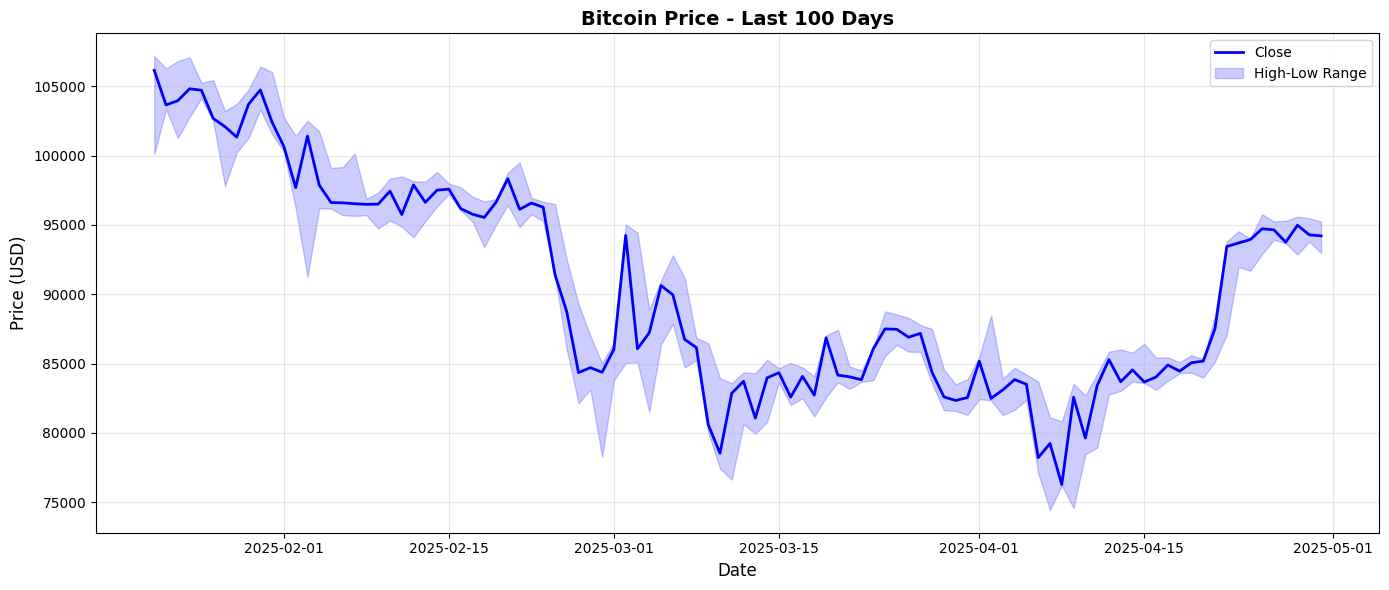

In [18]:
btc_recent=btc_data.tail(100)

fig,ax=plt.subplots(figsize=(14,6))

ax.plot(btc_recent.index,btc_recent['Close'],color='blue',linewidth=2, label='Close')
ax.fill_between(btc_recent.index,btc_recent['Low'],btc_recent['High'],
                color='blue',alpha=0.2,label='High-Low Range')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.set_title('Bitcoin Price - Last 100 Days', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/plots/05_recent_prices.png", dpi=150)
plt.show()

### Correlation analysis

Price       Open      High       Low     Close    Volume
Price                                                   
Open    1.000000  0.999602  0.999430  0.999153  0.650448
High    0.999602  1.000000  0.999294  0.999641  0.656862
Low     0.999430  0.999294  1.000000  0.999547  0.641009
Close   0.999153  0.999641  0.999547  1.000000  0.650261
Volume  0.650448  0.656862  0.641009  0.650261  1.000000


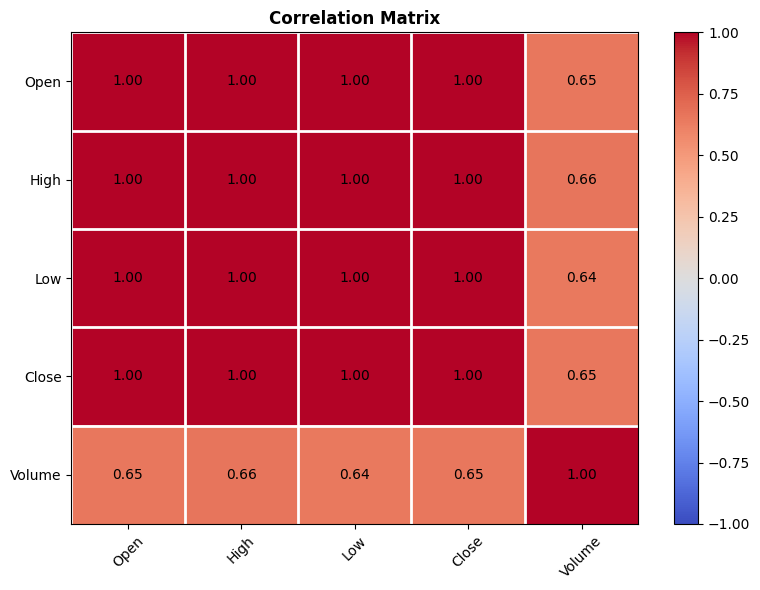

In [19]:
corr_matrix = btc_data[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
print(corr_matrix)

fig,ax=plt.subplots(figsize=(8,6))
im=ax.imshow(corr_matrix,cmap='coolwarm',aspect='auto',vmin=-1,vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns,rotation=45)
ax.set_yticklabels(corr_matrix.columns)


for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text=ax.text(j,i,f'{corr_matrix.iloc[i,j]:.2f}',
                     ha='center',va='center',color='black',fontsize=10)
        
ax.set_xticks(np.arange(len(corr_matrix.columns)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(corr_matrix.columns)) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

plt.colorbar(im,ax=ax)
ax.set_title('Correlation Matrix',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig("../results/plots/06_correlation_matrix.png", dpi=150)
plt.show()

## Preprocessing

In [20]:
data=btc_data[['Close']].values

print(f"Data shape: {data.shape}")
print(f"Data types: {type(data)}")
print(f"First 5 values:\n{data[:5]}")

Data shape: (3773, 1)
Data types: <class 'numpy.ndarray'>
First 5 values:
[[314.24899292]
 [315.03201294]
 [281.08200073]
 [264.19500732]
 [274.47399902]]


In [21]:
from src.preprocessing import normalize_data, create_sequences, train_test_split, save_arrays

In [22]:
data_normalized,scaler=normalize_data(data)
print(f"Normalized data shape: {data_normalized.shape}")
print(f"Min: {data_normalized.min():.6f}")
print(f"Max: {data_normalized.max():.6f}")
print(f"Mean: {data_normalized.mean():.6f}")

Normalized data shape: (3773, 1)
Min: 0.000000
Max: 1.000000
Mean: 0.209874


In [23]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [24]:
lookback=config['DATA']['lookback_window']
X,y=create_sequences(data_normalized,lookback=lookback)

Created sequences:
  X shape: (3713, 60, 1)
  y shape: (3713, 1)


In [25]:
train_split=config['DATA']['train_split']
valid_split=config['DATA']['validation_split']

X_train,X_valid,X_test,y_train,y_valid,y_test=train_test_split(X,y,train_ratio=train_split,valid_ratio=valid_split,test_ratio=1-train_split-valid_split)

Split sizes:
 X_train: (2599, 60, 1) y_train: (2599, 1)
 X_valid: (556, 60, 1) y_valid: (556, 1)
 X_test : (558, 60, 1) y_test : (558, 1)


In [26]:
save_arrays(X_train,X_valid,X_test,y_train,y_valid,y_test,scaler, folder='../data/processed')

### Visulizing of sequences

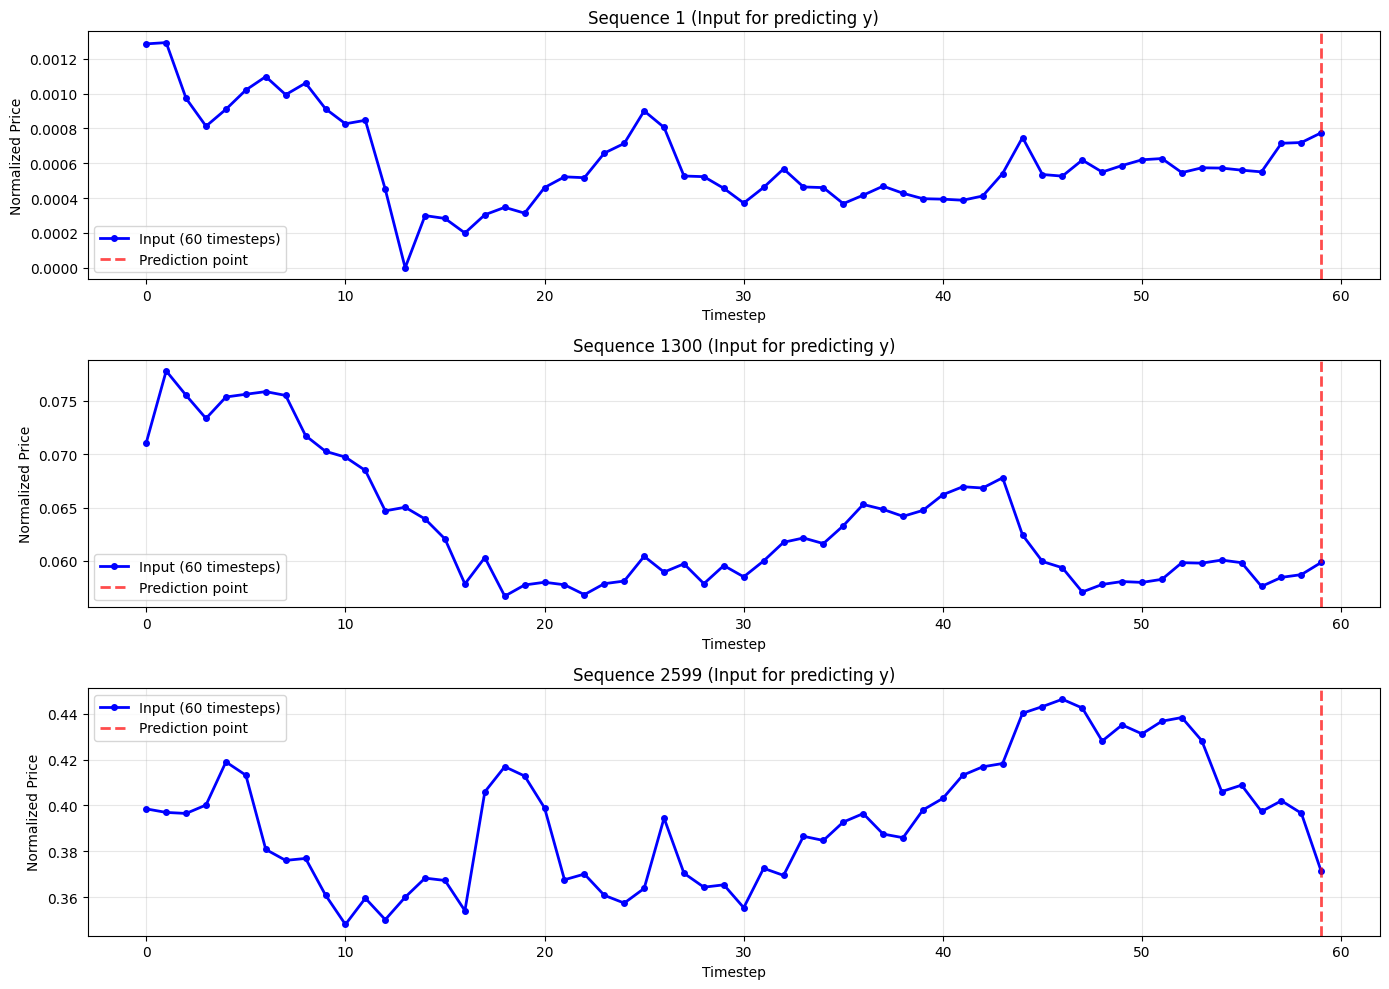

In [27]:
fig,axes=plt.subplots(3,1,figsize=(14,10))
i=0

for idx in [0, len(X_train)//2, len(X_train)-1]:
    ax = axes[i]
    
    ax.plot(X_train[idx].reshape(-1), 'o-', linewidth=2, markersize=4, 
            label='Input (60 timesteps)', color='blue')
    ax.axvline(x=59, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Prediction point')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Normalized Price')
    ax.set_title(f'Sequence {idx+1} (Input for predicting y)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    i+=1

plt.tight_layout()
plt.savefig("../results/plots/07_sample_sequences.png", dpi=150)
plt.show()